In [1]:
! pip install --upgrade tf-keras-vis tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.3/615.3 MB 2.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 3.3 MB/s eta 0:00:000:00:0100:01
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.17.1
    Uninstalling tensorboard-2.17.1:
      Successfully uninstalled tensorboard-2.17.1
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.17.1
    Uninstalling tensorflow-2.17.1:
      Successfully uninstalled tensorflow-2.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.10.0 requires tensorflow==2.17.0, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-text 2.17.0 requires tensorflow<2.18,>=2.17.0, but you have tensorflow 2.18.0 which is incom

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
from tf_keras_vis.utils import num_of_gpus
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import seaborn as sns
import os
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import AdamW
from tf_keras_vis.activation_maximization import ActivationMaximization
from tf_keras_vis.utils.callbacks import Print
from tensorflow.keras.applications import VGG19
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import backend as K
from tf_keras_vis.utils import normalize
from matplotlib import cm
from tf_keras_vis.gradcam import Gradcam
%reload_ext autoreload
%autoreload 2
%matplotlib inline

## **References:**

https://github.com/keisen/tf-keras-vis

# GradCAM, GradCAM++, and Faster-ScoreCAM Visualizations

```
Visualizing deep learning models, especially Convolutional Neural Networks (CNNs), is crucial for understanding how models make decisions. GradCAM, GradCAM++, and Faster-ScoreCAM are popular techniques for visualizing class-specific features, helping explain model behavior by highlighting important regions in an input image that contribute most to the model's prediction.
```

# 1. GradCAM (Gradient-weighted Class Activation Mapping)

**GradCAM is a technique that uses the gradients of the target class with respect to the final convolutional layer to create a class-discriminative localization map. It highlights the regions in the input image that influence the prediction most for a particular class.**


# How it works:

* GradCAM computes the gradients of the target class (the class you are interested in) with respect to the final convolutional layer of the model.
* The gradients are then globally pooled and used as weights for the feature maps in the final convolutional layer.
* A weighted sum of these feature maps produces the GradCAM heatmap.
* The heatmap highlights regions that were important for predicting the target class.

# Advantages:

* GradCAM is relatively simple to implement and can be applied to pre-trained models without requiring any changes to the architecture.
* It works with various types of CNNs, even without needing access to the fully connected layers.
# Applications:

* GradCAM is often used for visual explanations of model predictions in image classification tasks, especially for medical imaging, autonomous driving, and other domains where interpretability is crucial.

# 2. GradCAM++

> GradCAM++ is an extension of GradCAM that aims to address some of the limitations of the original GradCAM method. While GradCAM focuses on the gradients of the output layer, GradCAM++ extends the approach by incorporating higher-order gradients.

# How it works:
* GradCAM++ works similarly to GradCAM, but it modifies how the gradients are used. Instead of using just the first-order gradients, it computes higher-order gradients (i.e., second-order and third-order gradients).
^ This improves the localization and accuracy of the class activation map, especially in cases where the class is affected by small and complex regions within the image.
# Advantages:

* GradCAM++ can produce more precise heatmaps, making it better at identifying smaller or more intricate areas relevant to the model's decision.
* It handles cases where multiple regions in the image contribute to the model's decision more effectively than GradCAM.
# Applications:

* GradCAM++ is useful when dealing with images that have complex structures or multiple contributing factors, such as satellite imagery, medical imaging (e.g., cancer detection), or any task requiring high precision in explaining predictions.


# 3. Faster-ScoreCAM


> Faster-ScoreCAM is an extension of the ScoreCAM method that improves its speed without sacrificing the quality of the heatmaps. ScoreCAM is another visualization technique that uses a different approach than GradCAM to generate saliency maps.

# How it works:
* ScoreCAM uses the feature maps from the convolutional layers without relying on gradients. For each feature map, ScoreCAM computes how much the feature map influences the class prediction by occluding parts of the input image.
* The key idea in Faster-ScoreCAM is to speed up this process by reducing the computational complexity of occlusion operations. Instead of occluding every pixel, it performs fewer operations by directly focusing on the most informative regions, making it faster than traditional ScoreCAM.
# Advantages:

* Faster-ScoreCAM improves the speed of generating saliency maps while maintaining the interpretability and accuracy of ScoreCAM.
* It avoids the issues with gradients that GradCAM might have, especially in cases where gradients are noisy or vanishing.
# Applications:

* Faster-ScoreCAM is ideal for applications that require fast real-time visualizations of deep learning models without compromising interpretability. It is particularly useful in scenarios where model explanations need to be generated quickly, such as in medical diagnosis or autonomous systems.

# Load data

In [3]:
(x_train, y_train), (x_test, y_test)  = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(f"Train Data Shape : {x_train.shape}")
print(f"Test Data Shape : {x_test.shape}")
print(f"Train Label Shape : {y_train.shape}")
print(f"Test Label Shape : {y_test.shape}")

Train Data Shape : (60000, 28, 28)
Test Data Shape : (10000, 28, 28)
Train Label Shape : (60000,)
Test Label Shape : (10000,)


In [5]:
print ("Dimensions of x_train:" + str(x_train[0].shape))
print ("Labels in x_train:" + str(y_train.shape))
print("\n")
print ("Dimensions of x_test:" + str(x_test[0].shape))
print ("Labels in y_test:" + str(y_test.shape))

Dimensions of x_train:(28, 28)
Labels in x_train:(60000,)


Dimensions of x_test:(28, 28)
Labels in y_test:(10000,)


# Preprocess data

In [6]:
# Preprocess the data
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Resize images to 32x32 to match VGG19 input size requirement
x_train = tf.image.resize(x_train, (32, 32))
x_test = tf.image.resize(x_test, (32, 32))

# Convert grayscale to 3 channels by repeating the input image
x_train = tf.repeat(x_train, 3, axis=-1)  # Repeat to make it 3 channels
x_test = tf.repeat(x_test, 3, axis=-1)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [7]:
print(f"Train Data Shape : {x_train.shape}")
print(f"Test Data Shape : {x_test.shape}")
print(f"Train Label Shape : {y_train.shape}")
print(f"Test Label Shape : {y_test.shape}")

Train Data Shape : (60000, 32, 32, 3)
Test Data Shape : (10000, 32, 32, 3)
Train Label Shape : (60000, 10)
Test Label Shape : (10000, 10)


# Build Model

In [8]:

base_model = VGG19(weights="imagenet", include_top=False, input_shape=(32, 32, 3))
x = tf.keras.layers.Flatten()(base_model.output)
x = tf.keras.layers.Dense(1024, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)  # Convert to Functional API

# Compile Model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Summary of the model
model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,559,946 (78.43 MB)

 Trainable params: 20,559,946 (78.43 MB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [9]:
history = model.fit(x_train,
                    y_train,
                    batch_size = 32,
                    epochs = 10,
                    verbose = 1,
                    validation_data = (x_test, y_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 35ms/step - accuracy: 0.9226 - loss: 0.2540 - val_accuracy: 0.9867 - val_loss: 0.0448
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9861 - loss: 0.0581 - val_accuracy: 0.9939 - val_loss: 0.0261
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9895 - loss: 0.0466 - val_accuracy: 0.9928 - val_loss: 0.0355
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9932 - loss: 0.0307 - val_accuracy: 0.9931 - val_loss: 0.0340
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9921 - loss: 0.0356 - val_accuracy: 0.9922 - val_loss: 0.0340
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9953 - loss: 0.0236 - val_accuracy: 0.9936 - val_loss: 0.0341
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9947 - loss: 0.0258 - val_accuracy: 0.9923 - val_loss: 0.0296
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9960 -

# Loss & Accuracy Graph

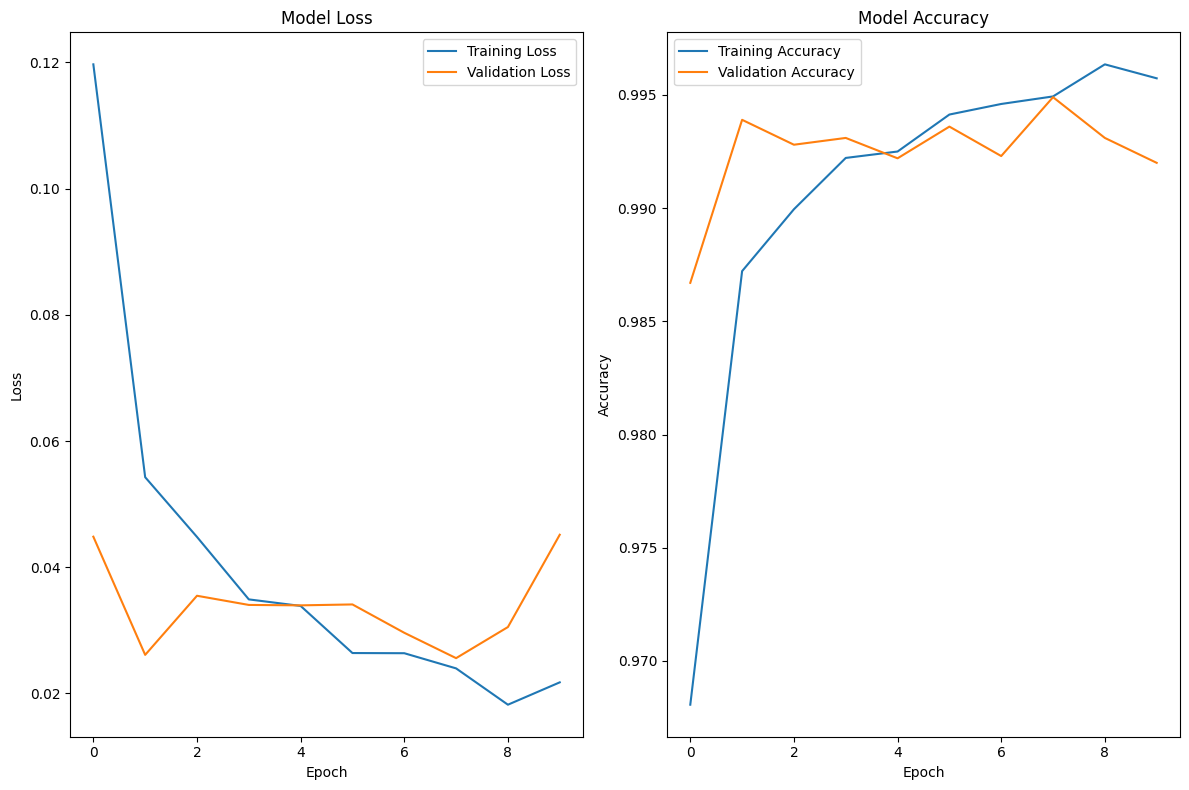

In [10]:
# Plotting Loss and Accuracy
plt.figure(figsize=(12, 8))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Model Evaluation

In [11]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.045151252299547195
Test accuracy: 0.9919999837875366


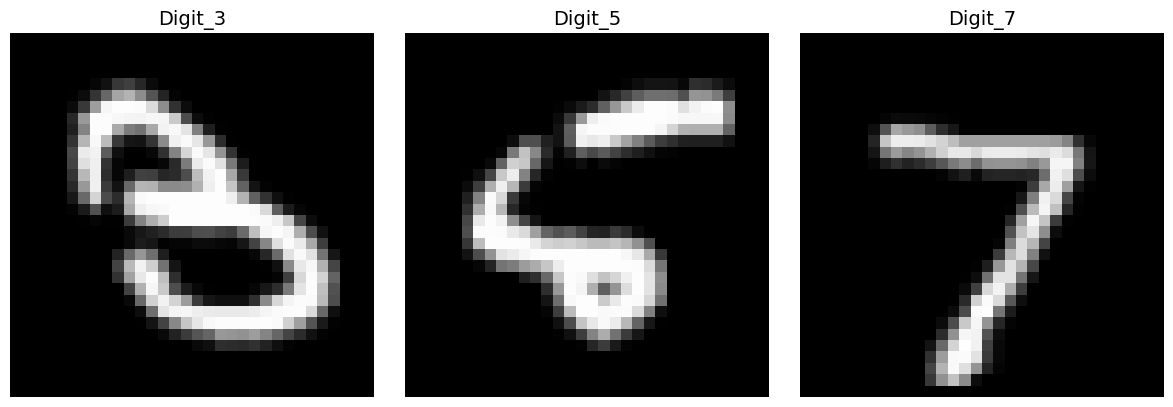

In [12]:

# Select images with labels 3, 5, and 7 from x_test and y_test
image_3 = x_test[np.where(np.argmax(y_test, axis=1) == 3)[0][0]]  # Image with label 3
image_5 = x_test[np.where(np.argmax(y_test, axis=1) == 5)[0][0]]  # Image with label 5
image_7 = x_test[np.where(np.argmax(y_test, axis=1) == 7)[0][0]]  # Image with label 7


# Convert grayscale to RGB if necessary
def convert_to_rgb(image):
    if image.shape[-1] == 1:
        image = np.squeeze(image, axis=-1)  # Remove single channel
        image = np.stack([image] * 3, axis=-1)  # Convert to RGB
    return image

image_3 = convert_to_rgb(image_3)
image_5 = convert_to_rgb(image_5)
image_7 = convert_to_rgb(image_7)


# Stack images
images = np.array([image_3, image_5, image_7])

# Image titles
image_titles = ["Digit_3", "Digit_5", "Digit_7"]

# Plotting the images
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Display each image
for i, title in enumerate(image_titles):
    ax[i].imshow(images[i])  # Display the image
    ax[i].set_title(title, fontsize=14)
    ax[i].axis('off')  # Turn off axes for clean display

plt.tight_layout()
plt.show()


# **Define necessary functions**

## **Define Loss functions**

> You MUST define loss function that return target scores. Here, it returns the scores corresponding three,five,seven digits

In [13]:
def loss(output):
    return [output[0, 3], output[1, 5], output[2, 7]]  # Class indices for each image

# **Define Model-Modifier function**

> Then, when the softmax activation function is applied to the last layer of model, it may obstruct generating the attention images, so you need to replace the function to a linear function. Here, we does so using model_modifier.

In [14]:
def model_modifier(m):
    m.layers[-1].activation = tf.keras.activations.linear
    return m

# **GradCAM**

GradCAM is another way of visualizing attention over input. Instead of using gradients with respect to model outputs, it uses penultimate (pre Dense layer) Conv layer output.

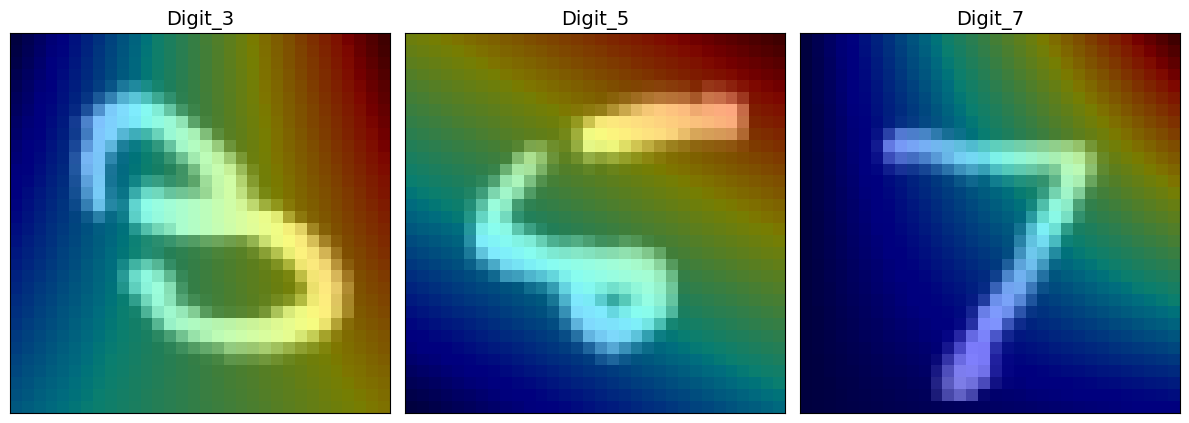

CPU times: user 883 ms, sys: 52.1 ms, total: 935 ms
Wall time: 956 ms


In [15]:
%%time
# Get last conv layer for Grad-CAM
last_conv_layer = base_model.get_layer("block5_conv4")
# Create Gradcam object
gradcam = Gradcam(model,model_modifier=model_modifier,clone=False)

# Generate heatmap with GradCAM
cam = gradcam(loss,images,penultimate_layer=last_conv_layer.name)
cam = normalize(cam)
subplot_args = {'nrows': 1, 'ncols': 3, 'figsize': (12, 8), 'subplot_kw': {'xticks': [], 'yticks': []}}

f, ax = plt.subplots(**subplot_args)
for i, title in enumerate(image_titles):
    heatmap = np.uint8(cm.jet(cam[i])[..., :3] * 255)
    ax[i].set_title(title, fontsize=14)
    ax[i].imshow(images[i])
    ax[i].imshow(heatmap, cmap='jet', alpha=0.5) # overlay
plt.tight_layout()
plt.show()

# **GradCAM++**

GradCAM++ can provide better visual explanations of CNN model predictions. In tf-keras-vis, GradcamPlusPlus (GradCAM++) class has most of compatibility with Gradcam. So you can use GradcamPlusPlus if you just replace classname from Gradcam to GradcamPlusPlus.

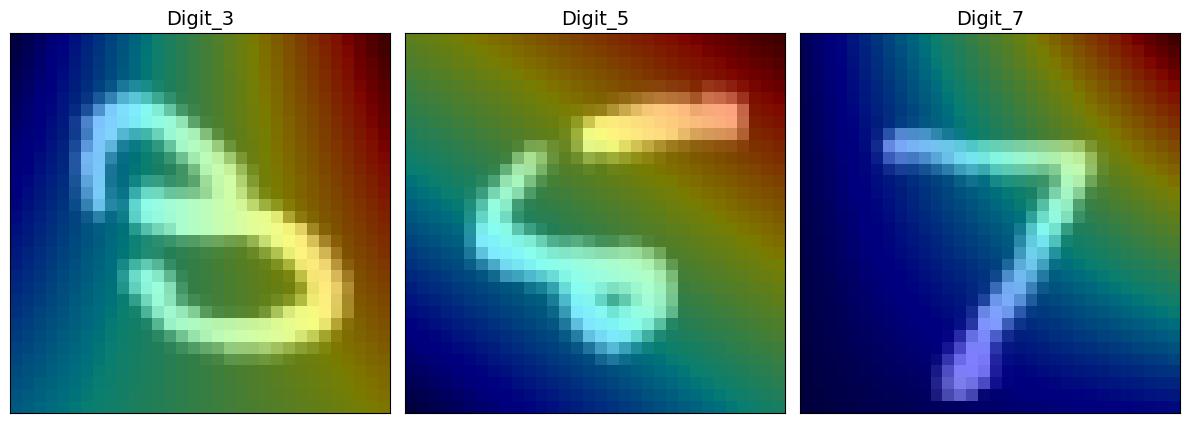

CPU times: user 720 ms, sys: 7.88 ms, total: 727 ms
Wall time: 679 ms


In [16]:
%%time

from tf_keras_vis.gradcam import GradcamPlusPlus

# Create GradCAM++ object, Just only repalce class name to "GradcamPlusPlus"
# gradcam = Gradcam(model, model_modifier, clone=False)
gradcam = GradcamPlusPlus(model,model_modifier=model_modifier,clone=False)

# Generate heatmap with GradCAM++
cam = gradcam(loss,images,penultimate_layer=last_conv_layer.name)
cam = normalize(cam)

f, ax = plt.subplots(**subplot_args)
for i, title in enumerate(image_titles):
    heatmap = np.uint8(cm.jet(cam[i])[..., :3] * 255)
    ax[i].set_title(title, fontsize=14)
    ax[i].imshow(images[i])
    ax[i].imshow(heatmap, cmap='jet', alpha=0.5)
plt.tight_layout()
plt.show()

As you can see above, Now, the visualized attentions almost completely cover the target objects!

## **ScoreCAM**

Lastly, Here, we show you ScoreCAM. SocreCAM is an another method that generate Class Activation Map. The characteristic is that it's the gradient-free CAM method unlike GradCAM/GradCAM++.

In default, this method takes too much time, so in the cell below ScoreCAM is NOT run with CPU.



In [17]:
_, gpus = num_of_gpus()
print('{} GPUs'.format(gpus))

1 GPUs


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


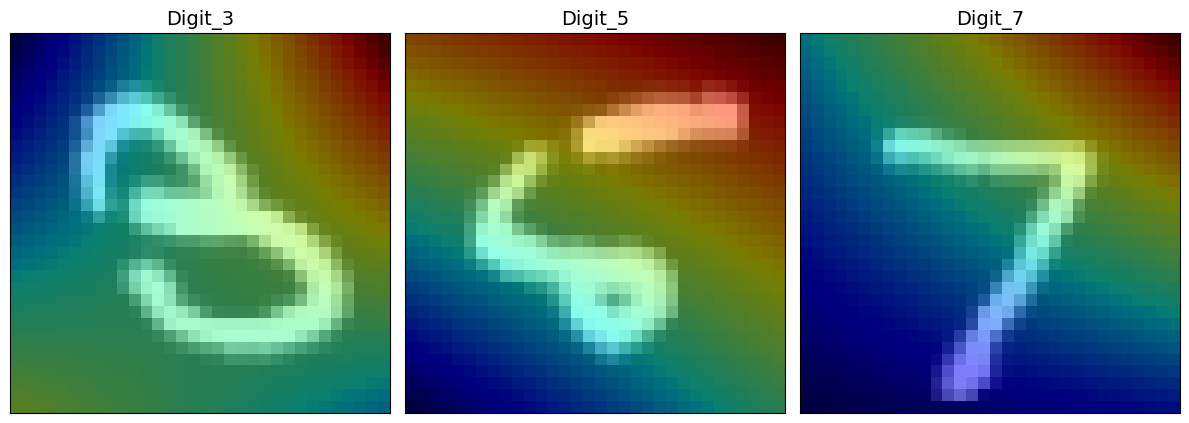

CPU times: user 2.2 s, sys: 109 ms, total: 2.31 s
Wall time: 2.33 s


In [18]:
%%time

from tf_keras_vis.scorecam import ScoreCAM

# Create ScoreCAM object
scorecam = ScoreCAM(model, model_modifier=model_modifier, clone=False)

# This cell takes toooooooo much time, so only doing with GPU.
if gpus > 0:
    # Generate heatmap with ScoreCAM
    cam = scorecam(loss,images,
                   penultimate_layer=last_conv_layer, # model.layers number
                  )
    cam = normalize(cam)

    f, ax = plt.subplots(**subplot_args)
    for i, title in enumerate(image_titles):
        heatmap = np.uint8(cm.jet(cam[i])[..., :3] * 255)
        ax[i].set_title(title, fontsize=14)
        ax[i].imshow(images[i])
        ax[i].imshow(heatmap, cmap='jet', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("NOTE: Change to GPU to see visual output\n")


# **Faster-ScoreCAM**

As you see above, ScoreCAM need huge processing power, but there is a good news for us. Faster-ScorecAM that makes ScoreCAM to be more efficient was devised by @tabayashi0117.

https://github.com/tabayashi0117/Score-CAM/blob/master/README.md#faster-score-cam

> We thought that several channels were dominant in generating the final heat map. Faster-Score-CAM adds the processing of “use only channels with large variances as mask images” to Score-CAM. (max_N = -1 is the original Score-CAM).

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step


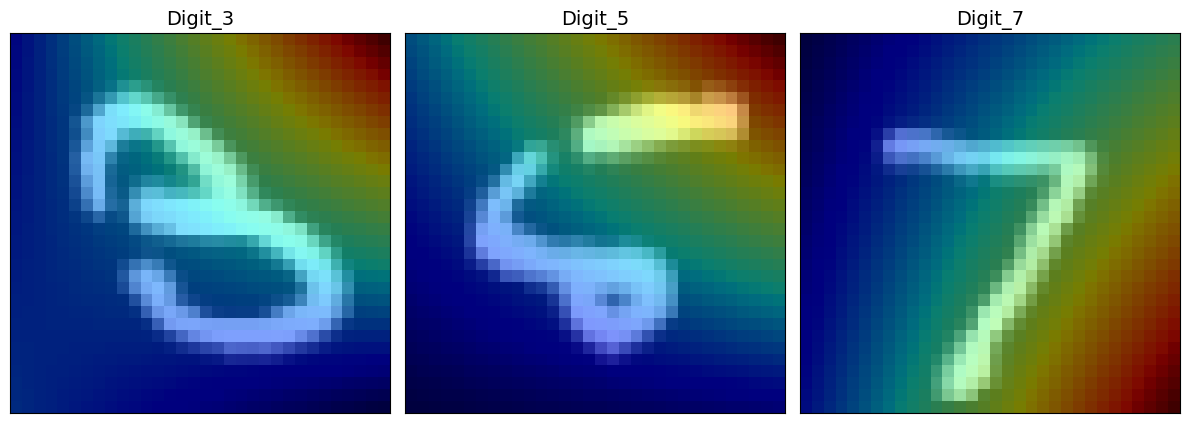

CPU times: user 1.59 s, sys: 48.9 ms, total: 1.64 s
Wall time: 1.71 s


In [19]:
%%time

# Create ScoreCAM object
scorecam = ScoreCAM(model,model_modifier=model_modifier, clone=False)

# Generate heatmap with Faster-ScoreCAM
cam = scorecam(loss,
               images,
               penultimate_layer=-1, # model.layers number
               max_N=10
              )
cam = normalize(cam)

f, ax = plt.subplots(**subplot_args)
for i, title in enumerate(image_titles):
    heatmap = np.uint8(cm.jet(cam[i])[..., :3] * 255)
    ax[i].set_title(title, fontsize=14)
    ax[i].imshow(images[i])
    ax[i].imshow(heatmap, cmap='jet', alpha=0.5)
plt.tight_layout()
plt.show()